# Import Libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset

In [2]:
df_order = pd.read_csv('data/orders.csv')
df_order_item = pd.read_csv('data/order_items.csv')
df_products = pd.read_csv('data/products.csv')

In [3]:
df_order_merge = pd.merge(df_order, df_order_item, on='order_id', how='left')

In [4]:
df_order_merge = pd.merge(df_order_merge, df_products, on='product_id', how='left')

In [5]:
df_order_merge['month_date'] = pd.to_datetime(df_order_merge['order_time']).dt.to_period('M').dt.to_timestamp()

In [6]:
df_order_merge.head()

,order_id,customer_id,order_time,payment_method,discount_pct,subtotal_usd,total_usd,country,device,source,product_id,unit_price_usd,quantity,line_total_usd,category,name,price_usd,cost_usd,margin_usd,month_date
0,1,13917,2025-01-31T23:07:42,card,20,107.15,85.72,PL,desktop,organic,226,107.15,1,107.15,Home & Kitchen,Toaster MediumSlateBlue 575,107.15,65.65,41.50,2025-01-01
1,2,1022,2024-02-19T01:17:50,card,0,116.17,116.17,FR,tablet,organic,771,116.17,1,116.17,Fashion,Socks Orange 300,116.17,70.22,45.95,2024-02-01
2,3,6145,2024-12-04T20:24:13,card,0,137.35,137.35,US,mobile,organic,415,94.49,1,94.49,Beauty,Shampoo LawnGreen 601,94.49,58.26,36.23,2024-12-01
3,3,6145,2024-12-04T20:24:13,card,0,137.35,137.35,US,mobile,organic,24,42.86,1,42.86,Electronics,SSD Orchid 272,42.86,27.37,15.49,2024-12-01
4,4,3152,2024-07-17T08:50:47,card,15,32.18,27.35,BR,mobile,email,1157,32.18,1,32.18,Toys,Board Game DarkSeaGreen 297,32.18,22.43,9.75,2024-07-01


# Pre Processing

In [7]:
def new_total(row):
    if row["discount_pct"] != 0:
        return (row["price_usd"] * (1 - row["discount_pct"] / 100)) * row["quantity"]
    else:
        return row["price_usd"] * row["quantity"]

df_order_merge["total_usd"] = df_order_merge.apply(new_total, axis=1)

In [8]:
df_order_merge = df_order_merge.drop(columns=['subtotal_usd'])

In [9]:
df_order_merge = df_order_merge.rename(columns={'line_total_usd' : 'subtotal'})

In [10]:
subtotal = df_order_merge.pop('subtotal') # Mengambil kolom 'Usia' dari posisinya yang lama
df_order_merge.insert(5, 'subtotal', subtotal)

In [11]:
df_order_merge= df_order_merge.drop(columns=['unit_price_usd'])

In [12]:
df_order_merge = df_order_merge.rename(columns={'margin_usd' : 'production_profit_usd'})

In [13]:
def sales_profit_usd(row):
    return row['total_usd'] - row['cost_usd']

df_order_merge["sales_profit_usd"] = df_order_merge.apply(sales_profit_usd, axis=1)

In [14]:
price_usd = df_order_merge.pop('price_usd') # Mengambil kolom 'Usia' dari posisinya yang lama
df_order_merge.insert(4, 'price_usd', price_usd)

In [15]:
quantity = df_order_merge.pop('quantity') # Mengambil kolom 'Usia' dari posisinya yang lama
df_order_merge.insert(5, 'quantity', quantity)

In [16]:
quantity = df_order_merge.pop('quantity') # Mengambil kolom 'Usia' dari posisinya yang lama
df_order_merge.insert(5, 'quantity', quantity)

In [17]:
price_usd = df_order_merge['price_usd'] # Mengambil kolom 'Usia' dari posisinya yang lama
df_order_merge.insert(15, 'prod_price_usd', price_usd)

In [18]:
sales_profit_usd = df_order_merge.pop('sales_profit_usd') # Mengambil kolom 'Usia' dari posisinya yang lama
df_order_merge.insert(18, 'sales_profit_usd', sales_profit_usd)

# EDA

## Volume Analysis

In [19]:
quantity_dist = df_order_merge.groupby(by=['product_id', 'name'])['quantity'].sum().reset_index().sort_values(by='quantity', ascending=False)

In [20]:
total_quantity = quantity_dist['quantity'].sum()

In [21]:
quantity_dist['percentage'] = 100 * (quantity_dist['quantity'] /  total_quantity)

In [22]:
quantity_dist.head(20)

,product_id,name,quantity,percentage
493,496,Lipstick LightBlue 766,179,0.232148
439,442,Lipstick RosyBrown 771,167,0.216585
923,926,E-book Gray 372,160,0.207507
401,404,Conditioner CornflowerBlue 855,159,0.206210
262,265,Vacuum LightCoral 663,157,0.203616
1060,1063,Action Figure DarkTurquoise 818,153,0.198428
1167,1170,Doll LightCyan 982,151,0.195834
941,944,E-book PeachPuff 118,151,0.195834
1084,1087,Building Blocks DarkCyan 517,150,0.194537
1025,1028,Puzzle Orchid 600,150,0.194537


In [23]:
quantity_tren = df_order_merge.groupby(by=['product_id', 'name', 'month_date'])['quantity'].sum().reset_index()

In [24]:
index_quantity = quantity_dist['name'][:5]

In [25]:
index_quantity

493            Lipstick LightBlue 766
439            Lipstick RosyBrown 771
923                   E-book Gray 372
401    Conditioner CornflowerBlue 855
262             Vacuum LightCoral 663
Name: name, dtype: str

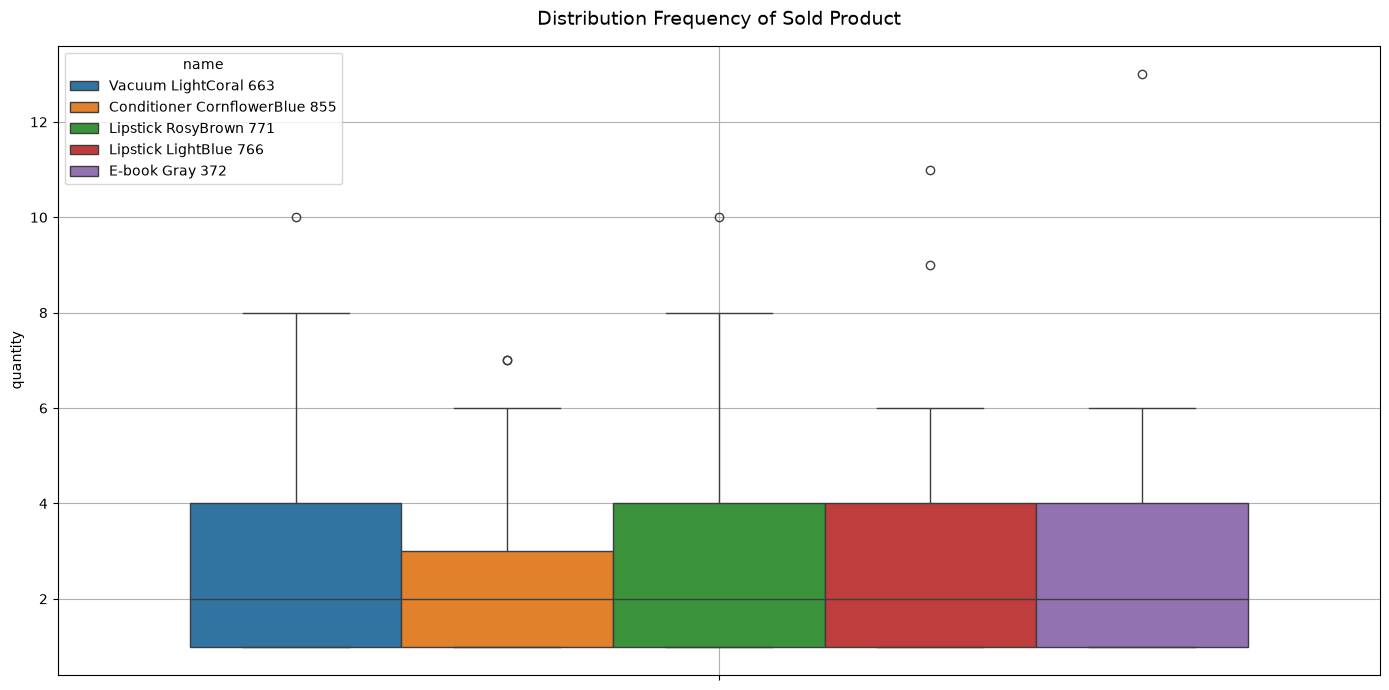

In [26]:

plt.figure(figsize=(14,7))
sns.boxplot(data=quantity_tren[quantity_tren['name'].isin(index_quantity)], y='quantity', hue='name')
plt.grid()
plt.title("Distribution Frequency of Sold Product", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

/tmp/ipykernel_13057/674839309.py:21: UserWarning: The palette list has more values (14) than needed (5), which may not be intended.
  sns.lineplot(


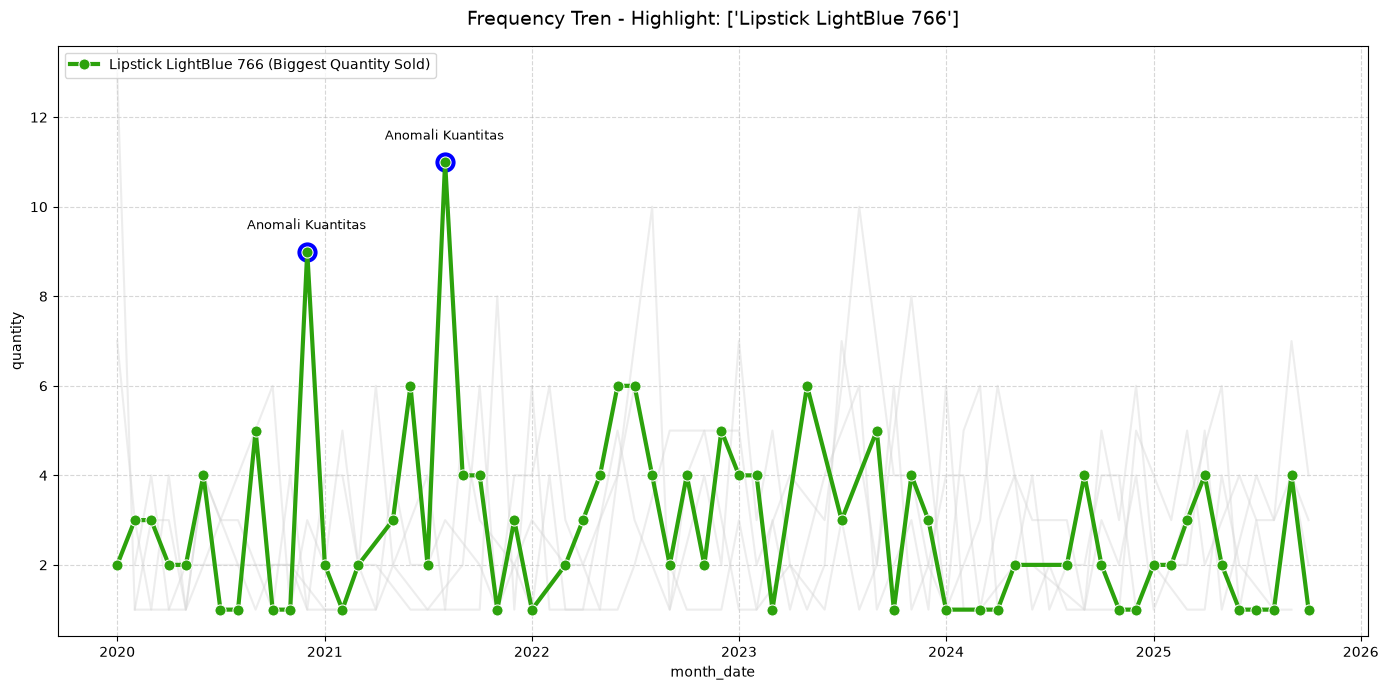

In [27]:
legend_labels = {
    "Lipstick LightBlue 766": "Lipstick LightBlue 766 (Biggest Quantity Sold)",
}

# 2. Adjust colors based on the new label names
product_colors = {
    "Lipstick LightBlue 766 (Biggest Quantity Sold)": "#2ca20c",
}

highlight_product = list(legend_labels.keys())

highlight_data = quantity_tren[
    quantity_tren["name"].isin(highlight_product)
].copy()

highlight_data["legend_name"] = highlight_data["name"].map(legend_labels)

plt.figure(figsize=(14, 7))

# 2. Plot SEMUA produk dulu dengan warna abu-abu & agak transparan
sns.lineplot(
    data=quantity_tren[quantity_tren['name'].isin(index_quantity)],
    x="month_date",
    y="quantity",
    hue="name",
    palette=["#d3d3d3"]
    * quantity_tren["quantity"].nunique(),  # Warna abu-abu untuk semua
    alpha=0.4,  # Membuat garis lain samar
    linewidth=1.5,
    legend=False,  # Sembunyikan legend default
)


sns.lineplot(
    data=highlight_data,
    x="month_date",
    y="quantity",
    marker="o",
    hue="legend_name",  
    palette=product_colors,
    markersize=8,
    linewidth=3,
)

Q1 = highlight_data['quantity'].quantile(0.25)
Q3 = highlight_data['quantity'].quantile(0.75)
IQR = Q3-Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = highlight_data[(highlight_data['quantity'] < lower_bound) | (highlight_data['quantity'] > upper_bound)]

sns.scatterplot(data=outliers, x='month_date', y='quantity', s=250, color='blue')

for out in range(outliers.shape[0]):
    # Kurangi 1 hari pakai pd.Timedelta jika month_date adalah Datetime
    x_pos = outliers['month_date'].iloc[out] - pd.Timedelta(days=1) 
    y_pos = outliers['quantity'].iloc[out] + 0.5
    val = outliers['quantity'].iloc[out]
    
    # Menampilkan nilai kuantitas sebagai label
    plt.text(x=x_pos, y=y_pos, s='Anomali Kuantitas', fontsize=9, ha='center')

# 4. Finishing
plt.title(f"Frequency Tren - Highlight: {highlight_product}", fontsize=14, pad=15)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

- Based on the plot and the table above, the most have anomalies in frequency distribution was **lipstic lightblue 766** and also this product was the best seller product accounting for 0.23% of total sales on this e-commerce platform.

## Revenue Analysis

In [28]:
revenue_dist = df_order_merge.groupby(by=['product_id', 'name'])['total_usd'].sum().reset_index().sort_values(by='total_usd', ascending=False)

In [29]:
total_revenue = revenue_dist['total_usd'].sum()

In [30]:
revenue_dist['percentage'] = 100 * (revenue_dist['total_usd'] /  total_revenue)

In [31]:
revenue_dist.head(20)

,product_id,name,total_usd,percentage
103,104,Mouse RosyBrown 419,9152.2440,0.203690
119,120,Headphones Aquamarine 465,8996.6650,0.200228
50,51,Webcam LightBlue 848,8694.5800,0.193505
8,9,Mouse Chartreuse 292,8443.6110,0.187919
153,156,Smartwatch Moccasin 101,8238.2720,0.183349
677,680,Tennis Racket PaleGreen 443,8191.1500,0.182300
530,533,Cycling Helmet DarkKhaki 165,8108.6400,0.180464
798,801,Hoodie BlanchedAlmond 225,8097.7440,0.180221
654,657,Water Bottle Gold 746,7695.7980,0.171276
621,624,Yoga Mat MediumTurquoise 462,7669.8200,0.170698


In [32]:
revenue_tren = df_order_merge.groupby(by=['product_id', 'name', 'month_date'])['total_usd'].sum().reset_index()

In [33]:
index_revenue = revenue_dist['name'][:5]

In [34]:
index_revenue.loc[6] = 'Lipstick LightBlue 766'

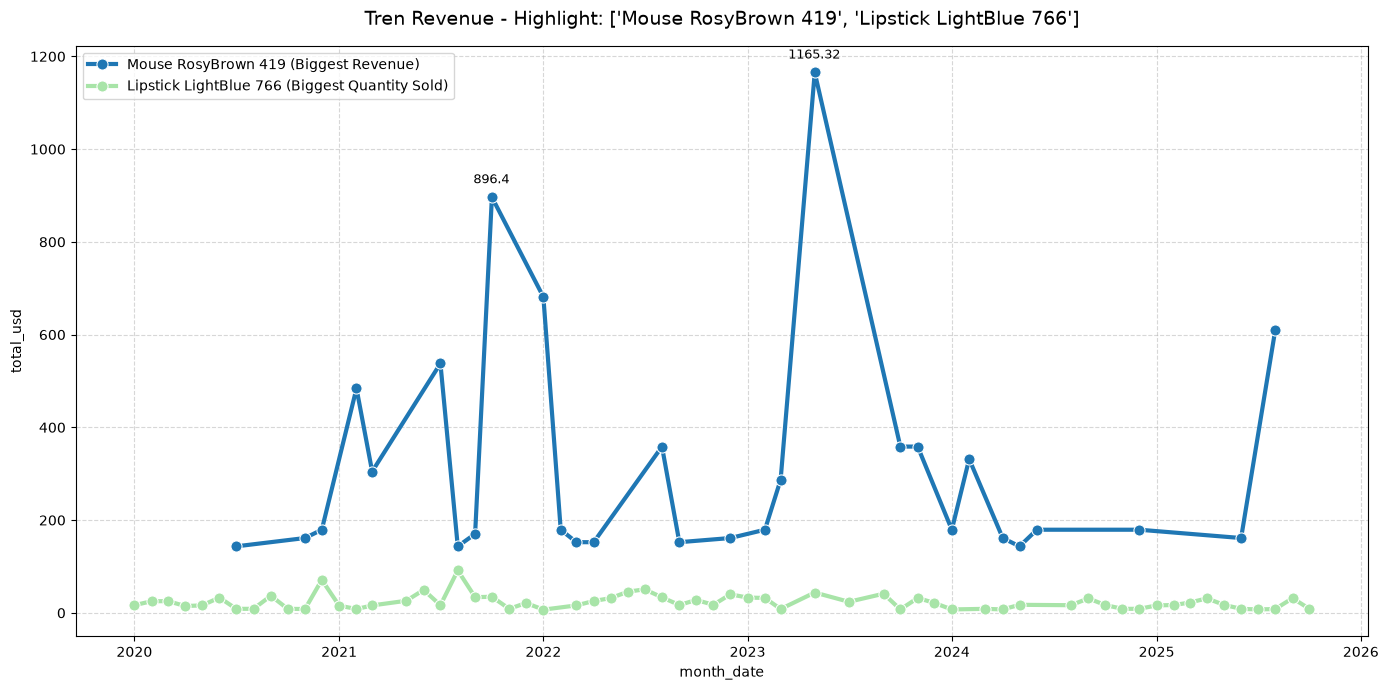

In [35]:
legend_labels = {
    "Mouse RosyBrown 419": "Mouse RosyBrown 419 (Biggest Revenue)",
    "Lipstick LightBlue 766": "Lipstick LightBlue 766 (Biggest Quantity Sold)",
}

# 2. Adjust colors based on the new label names
product_colors = {
    "Mouse RosyBrown 419 (Biggest Revenue)": "#1f77b4",
    "Lipstick LightBlue 766 (Biggest Quantity Sold)": "#a8e4a8",
}

highlight_product = list(legend_labels.keys())

highlight_data = revenue_tren[
    revenue_tren["name"].isin(highlight_product)
].copy()

highlight_data["legend_name"] = highlight_data["name"].map(legend_labels)

plt.figure(figsize=(14, 7))

sns.lineplot(
    data=highlight_data,
    x="month_date",
    y="total_usd",
    marker="o",
    hue="legend_name",  
    palette=product_colors,
    markersize=8,
    linewidth=3,
)

top_2 = highlight_data[highlight_data['name'] == 'Mouse RosyBrown 419'].sort_values(by=['total_usd'], ascending=False)[:2]

for out in range(top_2.shape[0]):
    # Kurangi 1 hari pakai pd.Timedelta jika month_date adalah Datetime
    x_pos = top_2['month_date'].iloc[out] - pd.Timedelta(days=1) 
    y_pos = top_2['total_usd'].iloc[out] + 30
    val = top_2['total_usd'].iloc[out]
    
    # Menampilkan nilai kuantitas sebagai label
    plt.text(x=x_pos, y=y_pos, s=f'{val}', fontsize=9, ha='center')


# 4. Finishing
plt.title(f"Tren Revenue - Highlight: {highlight_product}", fontsize=14, pad=15)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()


- Based on the plot and the table above, the biggest revenue product of this e-commerce was generated by **mouse roybrown 419** with the two highest monthly revenue figures being $896 and $1,165, respectively.
- Eventhough **lipstic lighgtblue 766** was the biggest quantity sold product it only generated smaller revenue compared to **mouse rosybrown 419**, it might happen because this product was cheaper compare than **mouse rosybrown 419**.
- Eventhough **lipstic lighgtblue 766** generated smaller revenue than **mouse rosybrown 419** this product had more stable revenue month by month compare to **mouse rosybrown 419**, so its a sign that this product has a loyal customer who bought this product regulary.

## Profit Analysis

In [36]:
sales_profit_dist = df_order_merge.groupby(by=['product_id', 'name'])['sales_profit_usd'].sum().reset_index().sort_values(by='sales_profit_usd', ascending=False)

In [37]:
total_sales_profit = sales_profit_dist['sales_profit_usd'].sum()

In [38]:
sales_profit_dist['percentage'] = 100 * (sales_profit_dist['sales_profit_usd'] /  total_sales_profit)

In [40]:
sales_profit_dist.head(20)

,product_id,name,sales_profit_usd,percentage
119,120,Headphones Aquamarine 465,6243.7050,0.298236
103,104,Mouse RosyBrown 419,5475.1840,0.261527
677,680,Tennis Racket PaleGreen 443,5104.6700,0.243829
67,68,Webcam SlateGray 700,4717.1175,0.225317
50,51,Webcam LightBlue 848,4684.4000,0.223754
654,657,Water Bottle Gold 746,4683.6780,0.223720
31,32,Mouse Yellow 529,4667.9450,0.222968
655,658,Yoga Mat Navy 102,4499.2600,0.214911
640,643,Water Bottle MistyRose 547,4402.8250,0.210305
149,151,Monitor DarkKhaki 939,4333.0680,0.206973


In [41]:
sales_profit_tren = df_order_merge.groupby(by=['product_id', 'name', 'month_date'])['sales_profit_usd'].sum().reset_index()

In [42]:
index_sales_profit = sales_profit_dist['name'][:5]

In [43]:
index_sales_profit.loc[6] = 'Lipstick LightBlue 766'

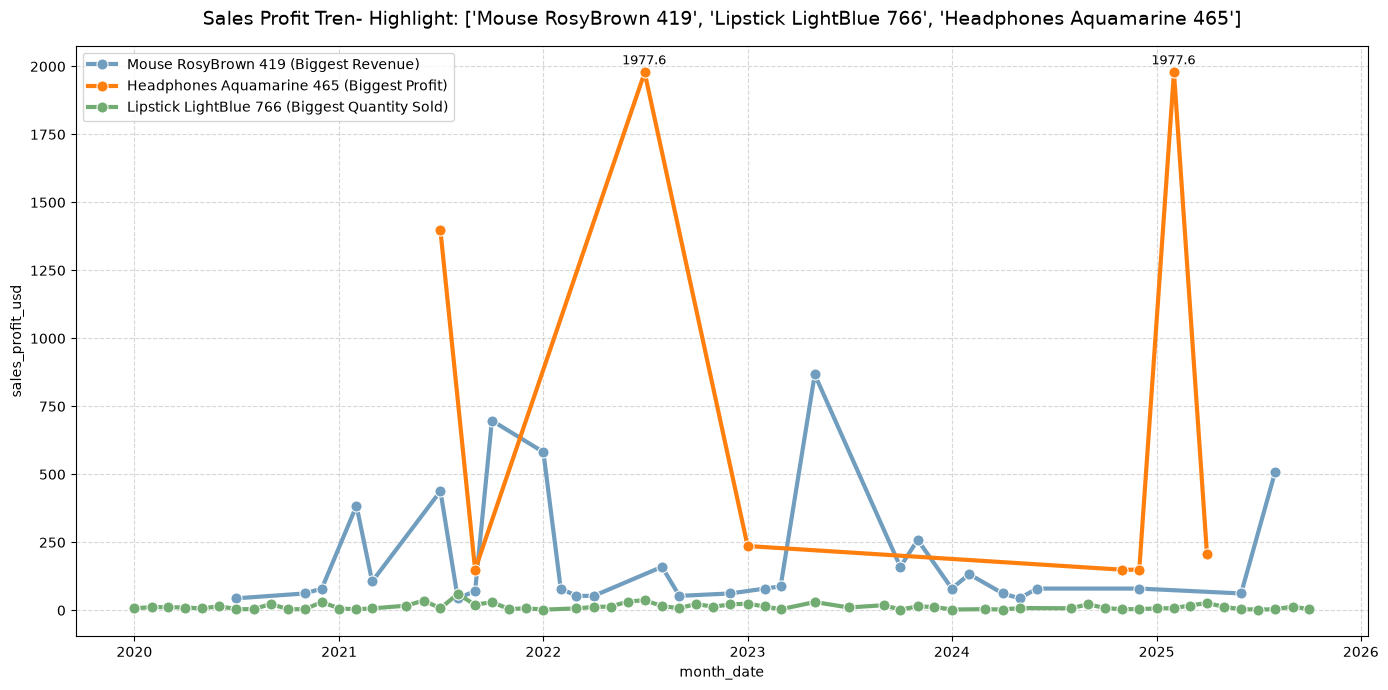

In [44]:
legend_labels = {
    "Mouse RosyBrown 419": "Mouse RosyBrown 419 (Biggest Revenue)",
    "Lipstick LightBlue 766": "Lipstick LightBlue 766 (Biggest Quantity Sold)",
    "Headphones Aquamarine 465": "Headphones Aquamarine 465 (Biggest Profit)",
}

# 2. Adjust colors based on the new label names
product_colors = {
    "Mouse RosyBrown 419 (Biggest Revenue)": "#719ebe",
    "Lipstick LightBlue 766 (Biggest Quantity Sold)": "#73ac73",
    "Headphones Aquamarine 465 (Biggest Profit)":  "#ff7f0e",
}

highlight_product = list(legend_labels.keys())

highlight_data = sales_profit_tren[
    sales_profit_tren["name"].isin(highlight_product)
].copy()

highlight_data["legend_name"] = highlight_data["name"].map(legend_labels)

plt.figure(figsize=(14, 7))


sns.lineplot(
    data=highlight_data,
    x="month_date",
    y="sales_profit_usd",
    marker="o",
    hue="legend_name",  
    palette=product_colors,
    markersize=8,
    linewidth=3,
)

top_2 = highlight_data[highlight_data['name'] == 'Headphones Aquamarine 465'].sort_values(by=['sales_profit_usd'], ascending=False)[:2]

for out in range(top_2.shape[0]):
    # Kurangi 1 hari pakai pd.Timedelta jika month_date adalah Datetime
    x_pos = top_2['month_date'].iloc[out] - pd.Timedelta(days=1) 
    y_pos = top_2['sales_profit_usd'].iloc[out] + 30
    val = top_2['sales_profit_usd'].iloc[out]
    
    # Menampilkan nilai kuantitas sebagai label
    plt.text(x=x_pos, y=y_pos, s=f'{val}', fontsize=9, ha='center')

plt.title(f"Sales Profit Tren- Highlight: {highlight_product}", fontsize=14, pad=15)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()


- Based on the table and plot above, the most profitable product was **headphones aquamarine 465** who generated 0.29% profit accros all sale.
- When compared to products generating the highest revenue and biggest quantity sold product, the **Aquamarine 465 headphones** exhibit an unstable profit pattern over time. Sales spike only during specific periods before declining; this indicates that the product is not one purchased routinely by consumers, it might happened because this product has greater durability compared to other products.

# Margin Analysis

In [45]:
cost_operation = df_order_merge.groupby(by=['product_id', 'name'])[['prod_price_usd', 'cost_usd', 'production_profit_usd']].first().reset_index()

In [46]:
cost_operation['margin'] = 100 * (cost_operation['production_profit_usd'] / cost_operation['prod_price_usd'])

In [47]:
cost_operation = cost_operation.sort_values(by=['margin'], ascending=False)

In [48]:
cost_operation.head()

,product_id,name,prod_price_usd,cost_usd,production_profit_usd,margin
1068,1071,Doll LightSkyBlue 279,45.01,22.51,22.50,49.988891
189,192,Lamp Tomato 228,196.45,98.31,98.14,49.956732
1180,1183,Doll DodgerBlue 971,73.81,36.96,36.85,49.925484
133,135,Webcam OrangeRed 916,308.90,154.76,154.14,49.899644
117,118,Mouse Lavender 472,183.35,91.87,91.48,49.893646


- Based on the table above the highest margin that a product had was generated by **Doll LightSkyBlue 279** with margin namely 49.99%.
- However, the sales performance of this product has been unsatisfactory in terms of volume, revenue, and profit.

# Conclusion

- The product with the highest quantity sold is Lipstick LightBlue 766, indicating it is the best-selling item by volume and likely has strong customer demand.
- The product generating the highest revenue is Mouse RosyBrown 419, showing that it contributes the most to total sales value even though it is not the top-selling item by quantity.
- The most profitable product in absolute profit is Headphones Aquamarine 465, but its sales profit trend is more volatile and less consistent over time.
- The product with the highest production margin is Doll LightSkyBlue 279, yet its overall sales volume, revenue, and profit performance remain weak, suggesting it is not currently a strong commercial performer despite good margin potential.

**Overall, the analysis shows:**

- A distinction between best-selling, highest revenue, and most profitable products.
- Opportunities to focus on stable high-revenue products like Mouse RosyBrown 419 while also exploring ways to boost volume or marketing for high-margin items like Doll LightSkyBlue 279.
- The need to balance product mix between volume-driven items, revenue drivers, and high-margin offerings to improve overall business performance.